# Overfitting and Regularization

## Imports

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error
from sklearn import set_config

In [4]:
set_config(display='diagram')

## Settings

In [5]:
SEED = 42
RANGE = (-5, 5)
N_SAMPLES = 50
DEGREES = np.linspace(0, 15, 1 + 15, dtype=int)
ALPHAS = np.linspace(0, 0.5, 1 + 40)

## Part 1: Underfitting vs. overfitting

### Generate samples

Let's pick a target function $ f(x) = 2\cdot x + 10\cdot sin(x) $ and generate some noisy samples to learn from.

In [6]:
def target_function(x):
    return 2 * x + 10 * np.sin(x)

def generate_samples():
    """Generate noisy samples."""
    np.random.seed(SEED)
    x = np.random.uniform(*RANGE, size=N_SAMPLES)
    y = target_function(x) + np.random.normal(scale=4, size=N_SAMPLES)
    return x.reshape(-1, 1), y

X, y = generate_samples()

### Plot samples

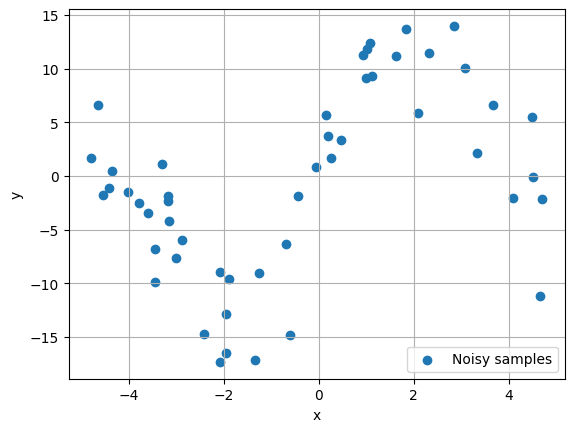

In [7]:
def plot_scatter(x, y, title=None, label='Noisy samples'):
    plt.scatter(x, y, label=label)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.grid(True)
    plt.title(title)
    plt.legend(loc='lower right')

plot_scatter(X, y)

### Split

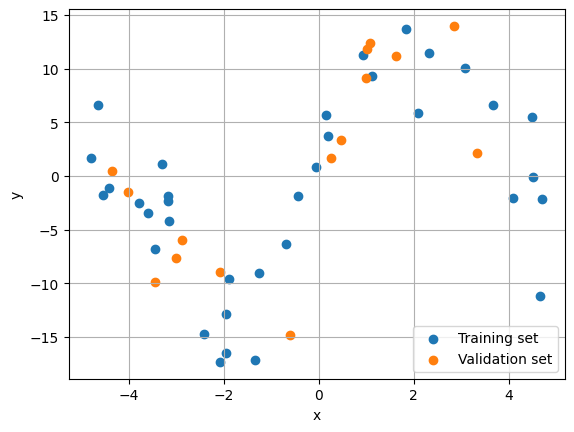

In [8]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.3, random_state=SEED)

plot_scatter(X_train, y_train, label='Training set')
plot_scatter(X_valid, y_valid, label='Validation set')

In [9]:
y_train

array([ -1.10771616,   0.84986647,  -9.62110024,   3.70972424,
        -2.36319095,   5.83708039, -16.53330524,  -1.8815588 ,
       -11.1506254 ,   1.0883081 ,  -9.05957818, -14.72254274,
         5.71746212,   5.48508317,  -6.81897956,  -1.80751907,
        -2.14124891, -12.83476672,  -0.09034969,  -3.48222266,
        11.50001273,  -2.03019037,  10.03142993, -17.18409407,
        -2.48182149,   1.67461593, -17.32081894,  -6.32825039,
        -4.15121484,   9.31494651,   6.5817456 ,   6.58351686,
        -1.83803375,  11.27589865,  13.68530977])

### Model

Let's try to approximate our target function $ f(x) = 2\cdot x + 10\cdot sin(x) $ with polynomials of different degree. 

A polynomial of degree $n$ has the form:
$ h(x) = w_0 + w_1\cdot x + w_2\cdot x^2 +\ldots + w_n\cdot x^n $.

$x^i$ values could easily be generated by `PolynomialFeatures`, while $w_i$ are the unknown paramaters to be estimated using `LinearRegression`.

In [10]:
PolynomialFeatures(degree=4, include_bias=False).fit_transform(X=[
    [1],
    [3],
    [4],
])

array([[  1.,   1.,   1.,   1.],
       [  3.,   9.,  27.,  81.],
       [  4.,  16.,  64., 256.]])

In [11]:
def make_model(degree, alpha=0, penalty=None):
    # linear regression
    if alpha == 0:
        regressor = LinearRegression()
    # lasso regression",
    elif penalty == 'L1':
        regressor = Lasso(alpha=alpha, random_state=SEED, max_iter=50000)
    # ridge regression",
    elif penalty == 'L2':
        regressor = Ridge(alpha=alpha, random_state=SEED, max_iter=50000) 
    
    
    return Pipeline([
        ('pol', PolynomialFeatures(degree, include_bias=(degree == 0))),
        ('sca', StandardScaler()),
        ('reg', regressor)
    ])

display(make_model(2))
display(make_model(2, penalty='L1', alpha=0.1))
display(make_model(2, penalty='L2', alpha=0.1))

Pipeline(steps=[('pol', PolynomialFeatures(include_bias=False)),
                ('sca', StandardScaler()), ('reg', LinearRegression())])

Pipeline(steps=[('pol', PolynomialFeatures(include_bias=False)),
                ('sca', StandardScaler()),
                ('reg', Lasso(alpha=0.1, max_iter=50000, random_state=42))])

Pipeline(steps=[('pol', PolynomialFeatures(include_bias=False)),
                ('sca', StandardScaler()),
                ('reg', Ridge(alpha=0.1, max_iter=50000, random_state=42))])

### Fit

Let's fit a model and plot the hypothesis it learns:

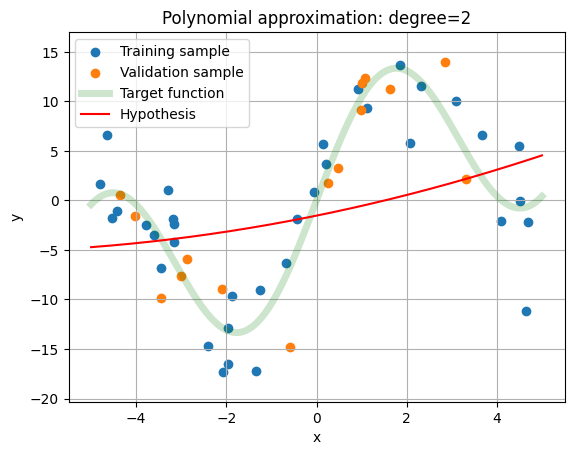

In [12]:
def plot_fit(model):
    degree = model['pol'].degree
    X_range = np.linspace(*RANGE, 1000).reshape(-1, 1)
    y_pred = model.predict(X_range)
    plot_scatter(X_train, y_train, label='Training sample')
    plot_scatter(X_valid, y_valid, label='Validation sample')
    plt.plot(X_range, target_function(X_range), c='green', alpha=0.2, lw=5, label='Target function')
    plt.plot(X_range, y_pred, c='red', label='Hypothesis')
    plt.ylim((min(y) - 3, max(y) + 3))
    plt.legend(loc='best')    
    plt.title(f'Polynomial approximation: degree={degree}')
    plt.show()

plot_fit(make_model(degree=2).fit(X_train, y_train))

### From underfitting to overfitting

We can investigate the shape of the fitted curve for different values of `degree`:

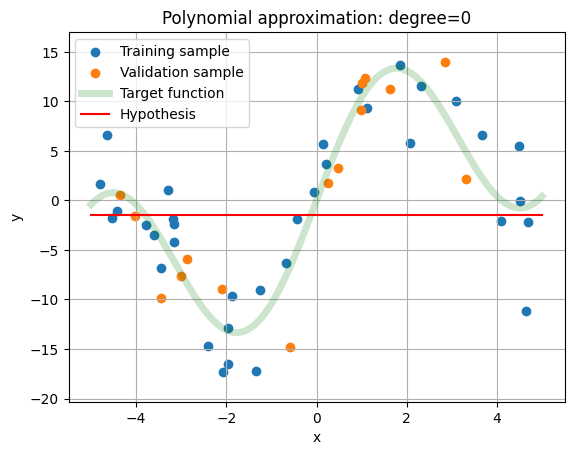

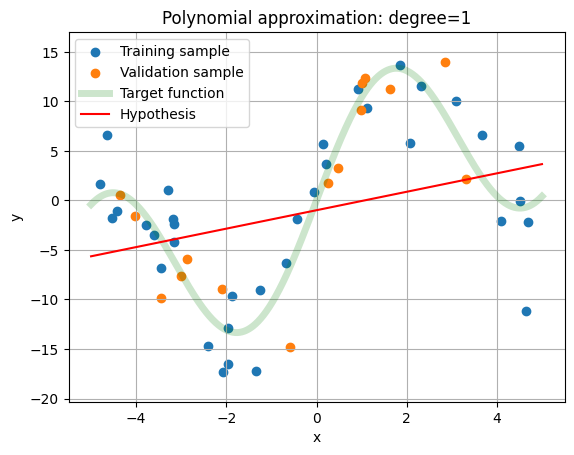

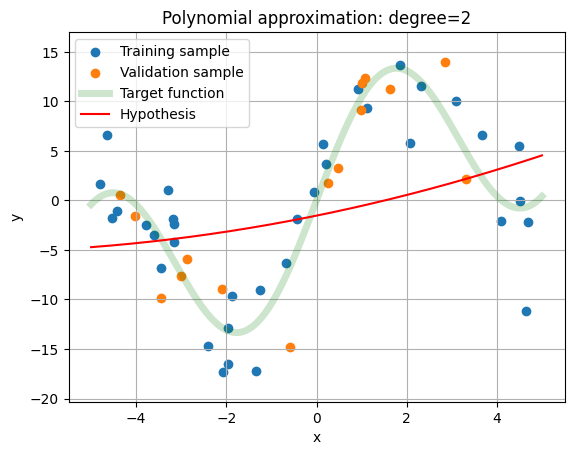

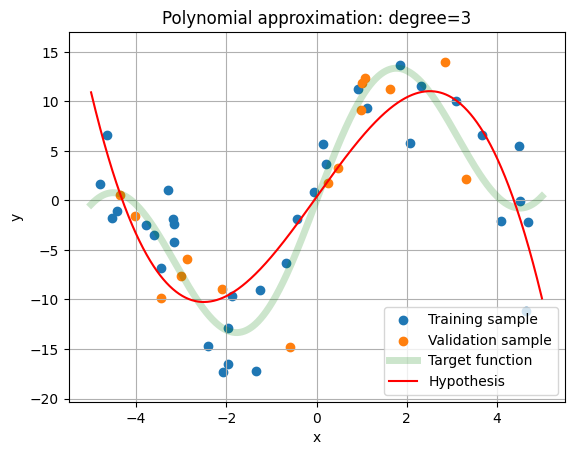

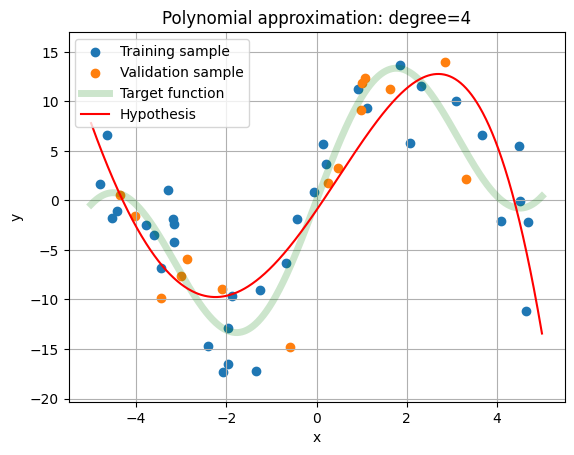

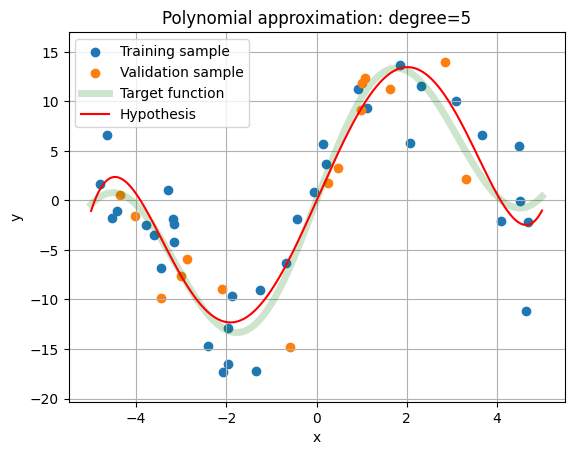

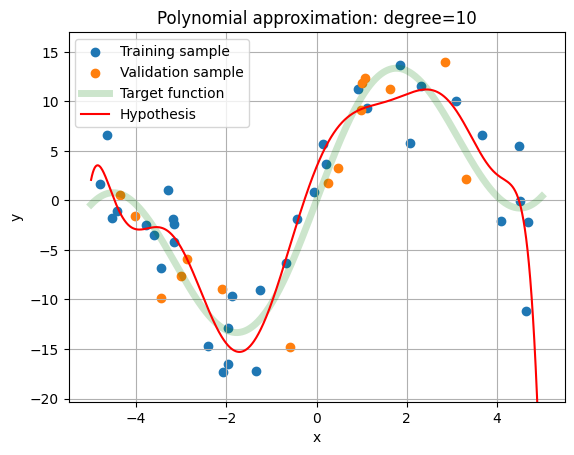

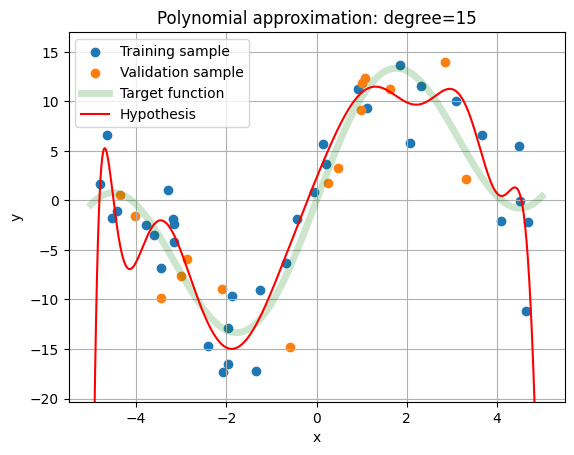

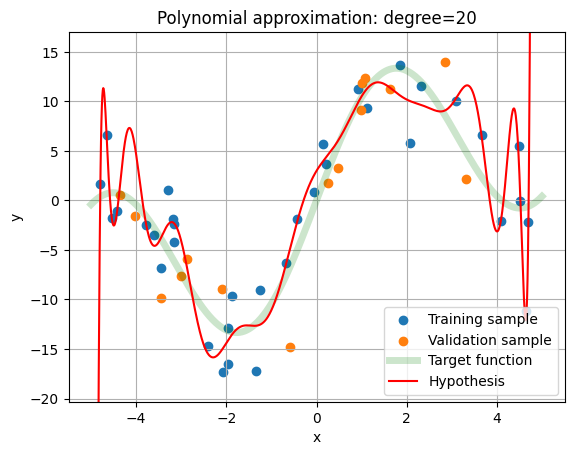

In [13]:
for degree in [0, 1, 2, 3, 4, 5, 10, 15, 20]:
    plot_fit(make_model(degree).fit(X_train, y_train))

### Fitting graph

In the next step we calculate the training and the validation error for each `degree` and plot them in a single graph. The resulting graph is called the fitting graph.

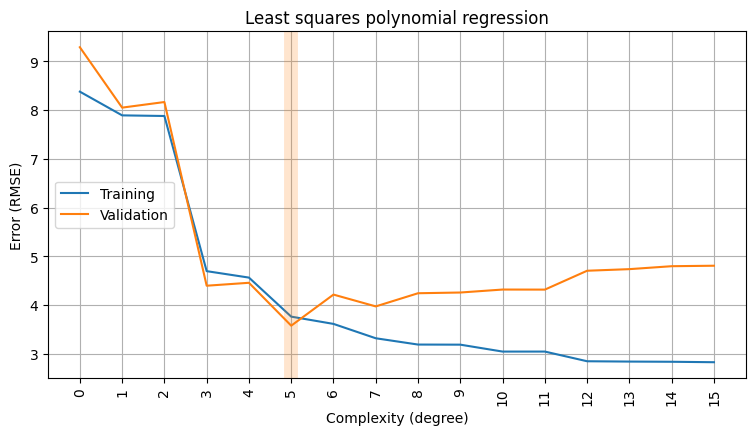

In [14]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def plot_fitting_graph(x, metric_train, metric_valid, xlabel, ylabel, 
                       custom_metric=None, custom_label='', custom_scale='log', title='Fitting graph'):
    plt.figure(figsize=(9, 4.5))
    plt.plot(x, metric_train, label='Training')
    plt.plot(x, metric_valid, color='C1', label='Validation')
    plt.axvline(x[np.argmin(metric_valid)], color='C1', lw=10, alpha=0.2)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.xticks(x, rotation='vertical')
    plt.legend(loc='center left')        
    if custom_metric:
        plt.twinx()
        plt.yscale(custom_scale)
        plt.plot(x, custom_metric, alpha=0.2, lw=4, ls='dotted', color='black', label=custom_label) 
        plt.legend(loc='center right')         
    plt.show()
    
rmse_train, rmse_valid = [], []
for degree in DEGREES:
    reg = make_model(degree).fit(X_train, y_train)
    rmse_train.append(rmse(reg.predict(X_train), y_train))
    rmse_valid.append(rmse(reg.predict(X_valid), y_valid))
    
plot_fitting_graph(DEGREES, rmse_train, rmse_valid, xlabel='Complexity (degree)', ylabel='Error (RMSE)', 
                   title='Least squares polynomial regression')

### Sweet spot

What is the optimal `degree` to go with?

In [ ]:
DEGREES[np.argmin(rmse_valid)]

np.int64(5)

### Cross-validation

Ideally, we would choose the the model parameters such that we have the best model performance. However, we want to make sure that we really have the best validation performance. When we do `train_test_split` we randomly split the data into two parts. What could happen is that we got lucky and split the data such that it favours the validation error. This is especially dangerous if we are dealing with small datasets. One way to check if that's the case is to run the experiment several times for different, random splits. However, there is an even more systematic way of doing this: [cross-validation](https://scikit-learn.org/stable/modules/cross_validation.html).

<img src="https://scikit-learn.org/stable/_images/grid_search_cross_validation.png" width=50% />

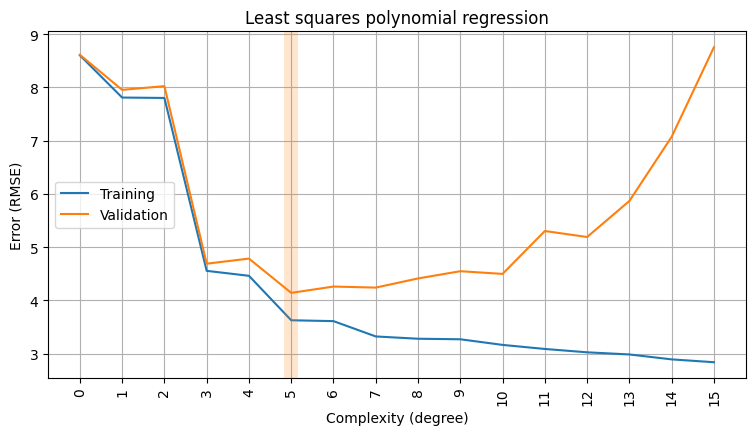

In [16]:
rmse_train, rmse_valid = [], []
for degree in DEGREES:
    results = cross_validate(make_model(degree), 
                             X, y, cv=5,
                             return_train_score=True,
                             scoring='neg_root_mean_squared_error')
    rmse_train.append(-np.mean(results['train_score']))
    rmse_valid.append(-np.mean(results['test_score']))
    
plot_fitting_graph(DEGREES, rmse_train, rmse_valid, xlabel='Complexity (degree)', ylabel='Error (RMSE)',
                   title='Least squares polynomial regression')

### Model coefficients

Let's inspect our regression model coefficients:

In [17]:
(make_model(degree=1).fit(X_train, y_train)['reg'].coef_,
 make_model(degree=2).fit(X_train, y_train)['reg'].coef_,
 make_model(degree=5).fit(X_train, y_train)['reg'].coef_,
 make_model(degree=10).fit(X_train, y_train)['reg'].coef_)

(array([2.81292778]),
 array([2.80049884, 0.45166501]),
 array([ 30.87315584,   1.48752361, -54.60227825,  -1.63699842,
         26.62792933]),
 array([  33.63850705,  -41.86346242,  -70.48743112,  278.98853452,
          27.48125634, -656.36383501,   59.32988346,  651.64795186,
         -47.55728814, -233.48455138]))

Hmm... it looks like high degree polynomials are coming with much bigger regression coefficients. 

We are going to plot the mean absolute value of $w_i$ as a function of degree to reveal the relationship:

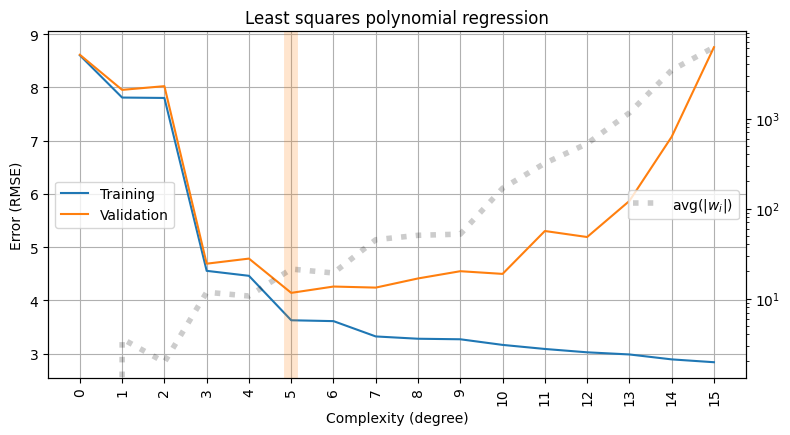

In [18]:
rmse_train, rmse_valid, avg_coef = [], [], []
for degree in DEGREES:
    results = cross_validate(make_model(degree),
                             X, y, cv=5,
                             return_train_score=True, return_estimator=True,
                             scoring='neg_root_mean_squared_error')
    rmse_train.append(-np.mean(results['train_score']))
    rmse_valid.append(-np.mean(results['test_score']))        
    avg_coef.append(        
        # average over CV folds
        np.mean([            
            # mean absolute value of weights
            np.mean(np.abs(model['reg'].coef_))
            for model in results['estimator']
        ]))
    
plot_fitting_graph(DEGREES, rmse_train, rmse_valid,
                   xlabel='Complexity (degree)', ylabel='Error (RMSE)',
                   custom_metric=avg_coef, custom_label='avg(|$w_i$|)',
                   title='Least squares polynomial regression')

### Summary

We observe the following:

1. **Underfitting** (degree < 5): The model is not able to fit the data properly. The fit is bad for both the training and the validation set.

2. **Fit is just right** (degree = 5): The model is able to capture the underlying data distribution. The fit is good for both the training and the validation set.

3. **Overfitting** (degree > 5): The model starts fitting the noise in the dataset. While the fit for the training data gets even better, the fit for the validation set gets worse.

4. As the order of polynomial increases, the linear model coefficients become more likely to take on **large values**.

## Part 2: Regularization

There are two major ways to build a machine learning model with the ability to generalize well on unseen data:
1. Train the simplest model possible for our purpose (according to Occam’s Razor).
2. Train a complex or more expressive model on the data and perform regularization.

Regularization is a method used to reduce the variance of a machine learning model. In other words, it is used to reduce overfitting. Regularization penalizes a model for being complex. For linear models, it means regularization forces model coefficients to be smaller in magnitude.

Let's pick a polynomial model of degree **15** (which tends to overfit strongly) and try to regularize it using **L1** and **L2** penalties.

### L1 - Lasso regression

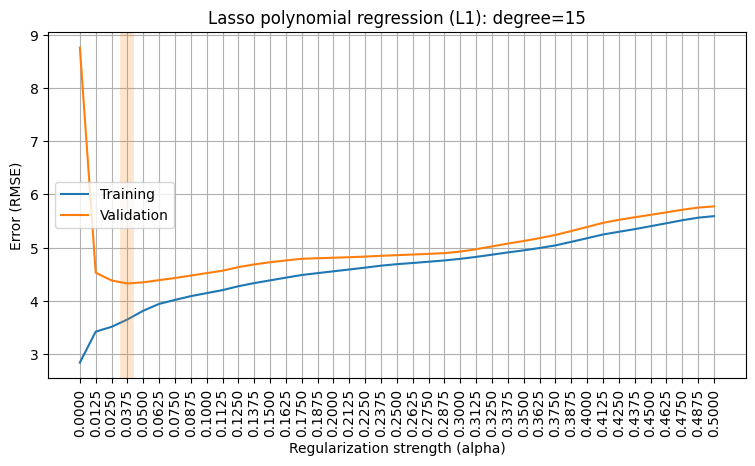

In [19]:
rmse_train, rmse_valid = [], []
for alpha in ALPHAS:    
    results = cross_validate(make_model(degree=15, penalty='L1', alpha=alpha), 
                             X, y, cv=5,
                             return_train_score=True,
                             scoring='neg_root_mean_squared_error')
    rmse_train.append(-np.mean(results['train_score']))
    rmse_valid.append(-np.mean(results['test_score']))
    
plot_fitting_graph(ALPHAS, rmse_train, rmse_valid,
                   xlabel='Regularization strength (alpha)', ylabel='Error (RMSE)',
                   title='Lasso polynomial regression (L1): degree=15')

### L2 - Ridge regression

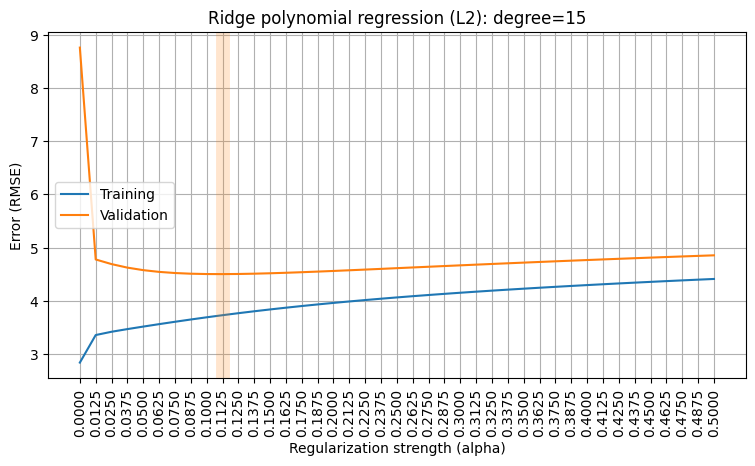

In [20]:
rmse_train, rmse_valid = [], []
for alpha in ALPHAS:    
    results = cross_validate(make_model(degree=15, penalty='L2', alpha=alpha), 
                             X, y, cv=5,
                             return_train_score=True,
                             scoring='neg_root_mean_squared_error')
    rmse_train.append(-np.mean(results['train_score']))
    rmse_valid.append(-np.mean(results['test_score']))
    
plot_fitting_graph(ALPHAS, rmse_train, rmse_valid, 
                   xlabel='Regularization strength (alpha)', ylabel='Error (RMSE)', 
                   title='Ridge polynomial regression (L2): degree=15')

### Summary

1. We can control the regularization strength by changing the hyperparameter `alpha`.
2. Regularized version of the model performs pretty well. Even in case the original original (unregularized) model is heavily overfitting due to excessive complexity.

## Part 3: Homework assignment (10 points)

**WARNING!**

Due to the limited power of your machine, you may face some difficulties in generating polynomial features of a high degree. It's ok to take only a subsample of features for that purpose (even one feature is enough). Afterwards, you **must collect all features together** (those which were used to generate polynomials and the rest).

### Excercise 1 - Overfiting and Underfitting (2 points)

Let's work with the diabetes dataset

In [21]:
from sklearn.datasets import load_diabetes
data = load_diabetes()
X_diabetes = pd.DataFrame(data['data'], columns=data['feature_names'])
y_diabetes = pd.DataFrame(data['target'], columns=['target'])
print(data['DESCR'])

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

Apply model for diabetes dataset with polynomial feature engineering of different degrees. Plot the dependence of train and test error on polynomial degree. Highlight a degree with the best test error. Which degrees cause overfitting/underfitting? Why?

<Axes: >

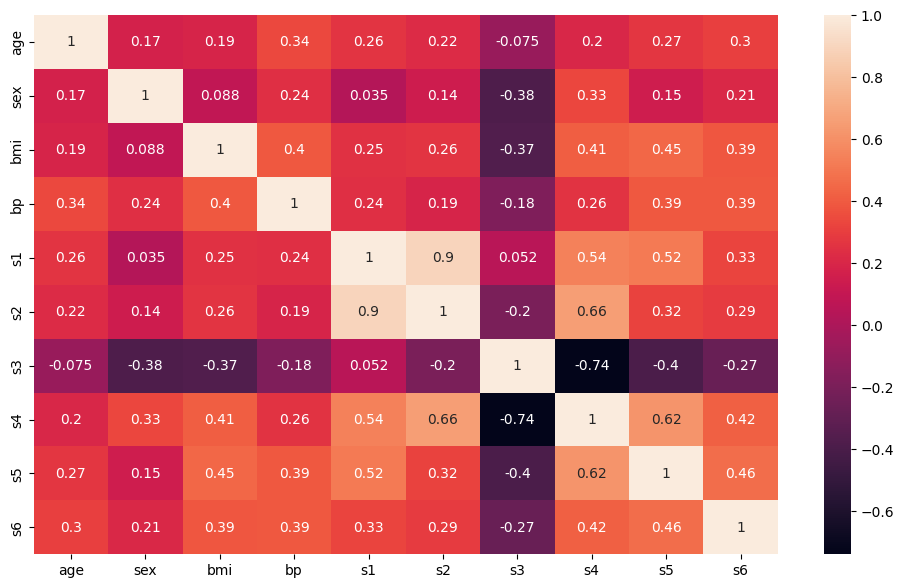

In [22]:
correlation_data = X_diabetes.corr(method='pearson')
plt.figure(figsize = (12,7))
sns.heatmap(correlation_data, annot = True)

Обучающая и тестовая выборка в отношении 70 на 30 (%)

In [23]:
X_train, X_valid, y_train, y_valid = train_test_split(X_diabetes, y_diabetes, test_size=0.3, random_state=SEED)

In [24]:
degrees = range(1, 11)
train_errors = []
test_errors = []

for degree in degrees:
    
    poly = PolynomialFeatures(degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_valid)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    train_predictions = model.predict(X_train_poly)
    test_predictions = model.predict(X_test_poly)
    
    train_error =  np.sqrt(mean_squared_error(y_train, train_predictions))
    test_error =  np.sqrt(mean_squared_error(y_valid, test_predictions))
    
    train_errors.append(train_error)
    test_errors.append(test_error)


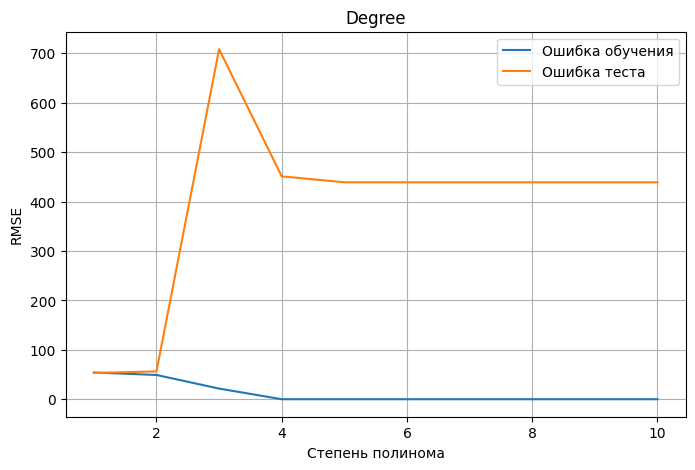

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(degrees, train_errors, label='Ошибка обучения')
plt.plot(degrees, test_errors, label='Ошибка теста')
plt.xlabel('Степень полинома')
plt.ylabel('RMSE')
plt.title('Degree')
plt.legend()
plt.grid(True)
plt.show()

На графике видно, что **degree = 3** является выбросом, попробуем исключить эту степень и попробовать еще раз

In [26]:
degrees = [1,2,4,5,6,7,8,9,10]
train_errors = []
test_errors = []

for degree in degrees:
    poly = PolynomialFeatures(degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_valid)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    train_predictions = model.predict(X_train_poly)
    test_predictions = model.predict(X_test_poly)
    
    train_error =  np.sqrt(mean_squared_error(y_train, train_predictions))
    test_error =  np.sqrt(mean_squared_error(y_valid, test_predictions))
    
    train_errors.append(train_error)
    test_errors.append(test_error)

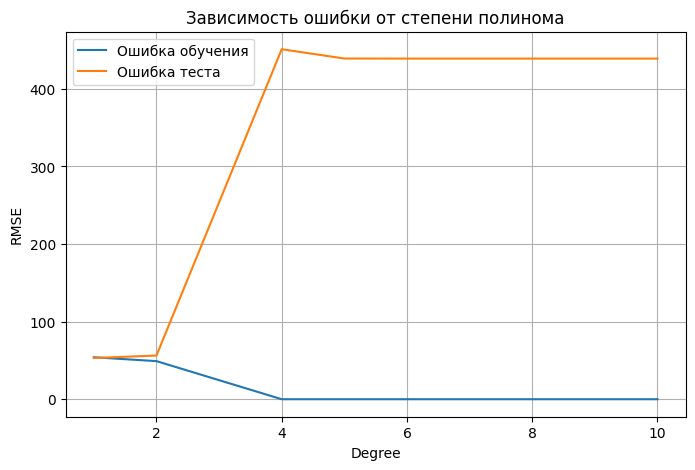

In [27]:
plt.figure(figsize=(8, 5))
plt.plot(degrees, train_errors, label='Ошибка обучения')
plt.plot(degrees, test_errors, label='Ошибка теста')
plt.xlabel('Degree')
plt.ylabel('RMSE')
plt.title('Зависимость ошибки от степени полинома')
plt.legend()
plt.grid(True)
plt.show()

Оптимальной степенью полинома для преобразования признаков является **degree = 1**.
При **degree > 1** модель будет переобученной.

### Excercise 2 - Magnitude (3 points)

As discussed earlier, regularization methods are expected to constraint the weights (model coefficients). 

Is it indeed happening? 

Please do a discovery on your own and find that out empirically (both for **L1** and **L2**). Let's use `degree=15` and `alpha` from `ALPHAS`.

In [28]:
from sklearn.model_selection import cross_val_score
bmi = X_diabetes[['bmi']]
simple_lr = LinearRegression().fit(bmi, y_diabetes)
mse = cross_val_score(simple_lr, bmi, y_diabetes, scoring='neg_mean_squared_error', cv = 10)
mse.mean()

np.float64(-3906.91899010684)

In [29]:
lr = LinearRegression().fit(X_diabetes, y_diabetes)
mse = cross_val_score(lr, X_diabetes, y_diabetes, scoring='neg_mean_squared_error', cv=10)
mse.mean()

np.float64(-3000.390290160842)

Использование всех признаков в модели **значительно увеличивае**т среднее значение neg_mean_squared_error (с -3906.92 до -3000.39)

#### L1

c:\Users\krekesh\Documents\GitHub\ml-intro\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.531e+02, tolerance: 2.044e+02
  model = cd_fast.enet_coordinate_descent(
c:\Users\krekesh\Documents\GitHub\ml-intro\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.871e+03, tolerance: 2.070e+02
  model = cd_fast.enet_coordinate_descent(
C:\Users\krekesh\AppData\Local\Temp\ipykernel_34012\2694836335.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.le

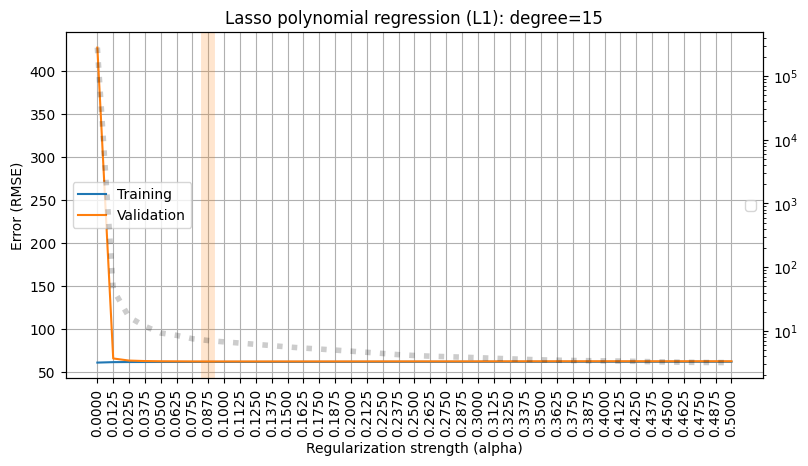

In [30]:
rmse_train, rmse_valid = [], []
avg_coef = []
bmi = X_diabetes[['bmi']]
degree = 15
poly = PolynomialFeatures(degree)
X_diabetes_poly = poly.fit_transform(bmi)

for alpha in ALPHAS:    
    l1_results = cross_validate(make_model(degree=1, penalty='L1', alpha=alpha), 
                             X_diabetes_poly, y_diabetes, cv=5,
                             return_estimator=True, return_train_score=True,
                             scoring='neg_root_mean_squared_error')
    rmse_train.append(-np.mean(l1_results['train_score']))
    rmse_valid.append(-np.mean(l1_results['test_score']))
    avg_coef.append(        
        # average over CV folds
        np.mean([            
            # mean absolute value of weights
            np.mean(np.abs(model['reg'].coef_))
            for model in l1_results['estimator']
        ]))
    
plot_fitting_graph(ALPHAS, rmse_train, rmse_valid, custom_metric = avg_coef ,
                   xlabel='Regularization strength (alpha)', ylabel='Error (RMSE)',
                   title='Lasso polynomial regression (L1): degree=15')

#### L2

C:\Users\krekesh\AppData\Local\Temp\ipykernel_34012\2694836335.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='center right')


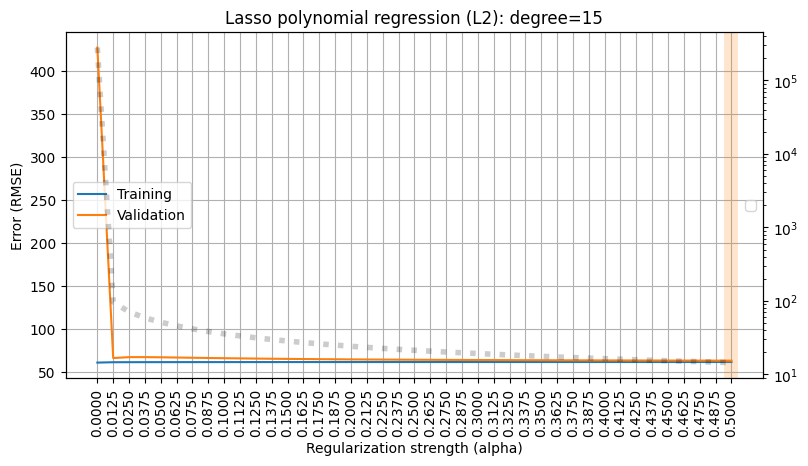

In [31]:
rmse_train_l2, rmse_valid_l2 = [], []
avg_coef_l2 = []
for alpha in ALPHAS:    
    l2_results = cross_validate(make_model(degree=1, penalty='L2', alpha=alpha), 
                             X_diabetes_poly, y_diabetes, cv=5,
                             return_estimator=True, return_train_score=True,
                             scoring='neg_root_mean_squared_error')
    rmse_train_l2.append(-np.mean(l2_results['train_score']))
    rmse_valid_l2.append(-np.mean(l2_results['test_score']))
    avg_coef_l2.append(        
        np.mean([            
            np.mean(np.abs(model['reg'].coef_))
            for model in l2_results['estimator']
        ]))
    
plot_fitting_graph(ALPHAS, rmse_train_l2, rmse_valid_l2, custom_metric = avg_coef_l2,
                   xlabel='Regularization strength (alpha)', ylabel='Error (RMSE)',
                   title='Lasso polynomial regression (L2): degree=15')

L2-регуляризация модели линейной регрессии увеличивает среднее значение с -3000.39 до -2997.19, когда L1-регуляризация увеличивает до -2987.43, что говорит о том, что L1-регуляризация приводит к лучшим результатам, нежели L2.
Используем найденное лучшее значение alpha:

#### Summary

In [32]:
## your observations/conclusions

### Excercise 3 - Sparsity (3 points)

Lasso can also be used for **feature selection** since L1 is [more likely to produce zero coefficients](https://explained.ai/regularization/).

Is it indeed happening? 

Please do a discovery on your own and find that out empirically (both for **L1** and **L2**). Let's use `degree=15` and `alpha` from `ALPHAS`.

#### L1

In [33]:
not_null_l1 = []
degree = 15
for alpha in ALPHAS:    
    l1_results = cross_validate(make_model(degree=1, penalty='L1', alpha=alpha), 
                             X_diabetes_poly, y_diabetes, cv=5,
                             return_estimator=True, return_train_score=True,
                             scoring='neg_root_mean_squared_error')
    not_null_l1.append(        
        np.mean([            
            np.mean(np.sum(model['reg'].coef_ != 0 ))
            for model in l1_results['estimator']
        ]))

c:\Users\krekesh\Documents\GitHub\ml-intro\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.531e+02, tolerance: 2.044e+02
  model = cd_fast.enet_coordinate_descent(
c:\Users\krekesh\Documents\GitHub\ml-intro\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.871e+03, tolerance: 2.070e+02
  model = cd_fast.enet_coordinate_descent(


#### L2

In [34]:
not_null_l2 = []
degree = 15
for alpha in ALPHAS:    
    l2_results = cross_validate(make_model(degree=1, penalty='L2', alpha=alpha), 
                             X_diabetes_poly, y_diabetes, cv=5,
                             return_estimator=True, return_train_score=True,
                             scoring='neg_root_mean_squared_error')
    not_null_l2.append(        
        np.mean([            
            np.mean(np.sum(model['reg'].coef_ != 0 ))
            for model in l2_results['estimator']
        ]))

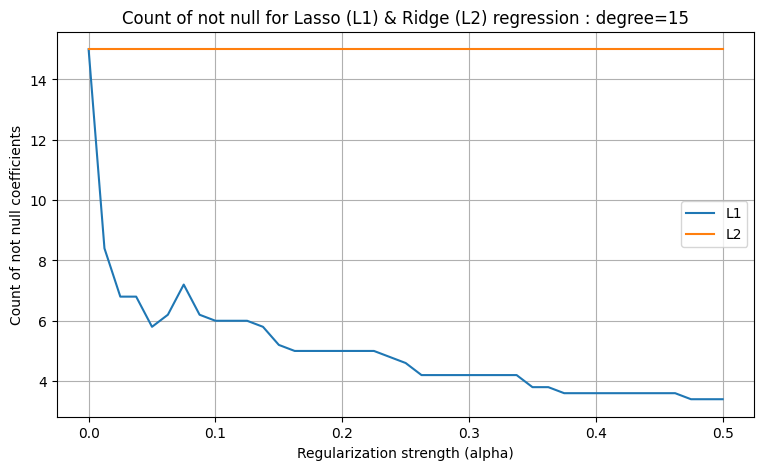

In [35]:
plt.figure(figsize=(9, 5))
plt.plot(ALPHAS, not_null_l1, label='L1')
plt.plot(ALPHAS, not_null_l2, label='L2')
plt.title('Count of not null for Lasso (L1) & Ridge (L2) regression : degree=15')
plt.ylabel('Count of not null coefficients')
plt.xlabel('Regularization strength (alpha)')
plt.grid(True)
plt.legend(loc='center right')  

#### Summary

L1-регуляризация действительно может давать нулевые коэффициенты, в отличие от L2-регуляризации.

### Excercise 4 - Scaling (2 points)

As a general rule, it is recommended to scale input features before fitting a regularized model so that the features/inputs take values in similar ranges. One common way of doing so is to standardize the inputs and that is exactly what our pipeline  second step (`StandardScaler`) is responsible for. 

Is scaling important? What are the underlying reasons?

Please do a discovery on your own and find that out empirically (both for **L1** and **L2**) on the dataset below. Check coefficients.

Как правило, рекомендуется масштабировать входные признаки перед подгонкой регуляризованной модели, чтобы признаки/входные признаки принимали значения в схожих диапазонах. Один из распространенных способов сделать это — стандартизировать входные признаки, и именно за это отвечает наш второй шаг конвейера (StandardScaler).

Важно ли масштабирование? Каковы основные причины?

Пожалуйста, сделайте открытие самостоятельно и выясните это эмпирическим путем (как для L1, так и для L2) на наборе данных ниже. Проверьте коэффициенты

In [36]:
def target_function_hw(x):
    return 2 * x

def generate_samples_hw():
    np.random.seed(SEED)
    x = np.random.uniform(*RANGE, size=N_SAMPLES)
    
    np.random.seed(SEED+1)
    x_noise = np.random.uniform(*[x * 100 for x in RANGE], size=N_SAMPLES)
    x_noise2 = np.random.normal(100, 50, size=N_SAMPLES)
    
    y = target_function_hw(x) + np.random.normal(scale=4, size=N_SAMPLES)
    
    return np.concatenate([x.reshape(-1, 1) / 100, 
                           x_noise.reshape(-1, 1),
                           x_noise2.reshape(-1, 1)], axis=1), y

X_hw, y_hw = generate_samples_hw()

for i in range(X_hw.shape[1]):
    print(f'Min of feature {i}: {min(X_hw[:, i]):.2f}, max: {max(X_hw[:, i]):.2f}')

Min of feature 0: -0.05, max: 0.05
Min of feature 1: -494.87, max: 493.57
Min of feature 2: -2.35, max: 213.31


Посмотрим на сгенерированные данные:

In [37]:
xhw = pd.DataFrame(X_hw)
xhw.head()

,0,1,2
0,-0.012546,-384.945434,80.667093
1,0.045071,109.066539,182.952436
2,0.023199,-366.609036,-2.353457
3,0.009866,-259.410380,169.965849
4,-0.034398,-172.860944,66.049644


In [57]:
yhw = pd.DataFrame(y_hw)
yhw.head()

,0
0,3.556569
1,2.478158
2,11.767762
3,-0.497741
4,-11.225224


In [38]:
scaler = StandardScaler()
X_hw_scaler = pd.DataFrame(scaler.fit_transform(X_hw))
X_hw_scaler.head()

,0,1,2
0,-0.249611,-1.302825,-0.455868
1,1.765126,0.295817,1.619440
2,1.000316,-1.243488,-2.140304
3,0.534075,-0.896589,1.355950
4,-1.013726,-0.616511,-0.752447


In [39]:
X_train_t4, X_test_t4, y_train_t4, y_test_t4 = train_test_split(X_hw, y_hw, test_size=0.3, random_state=42)
X_train_scaler, X_test_scaler = scaler.fit_transform(X_train_t4), scaler.transform(X_test_t4) #нормализировали

#### L1

In [82]:
MAX_DEGREE = 15
DEGREES = np.linspace(1, MAX_DEGREE, MAX_DEGREE+1, dtype=int)

# With StandardScaler
rmse_train_scaler, rmse_test_scaler = [], []
for degree in DEGREES:
    reg = make_model(degree,penalty='L1', alpha=0.1 ).fit(X_train_scaler, y_train_t4)
    rmse_train_scaler.append(rmse(reg.predict(X_train_scaler), y_train_t4))
    rmse_test_scaler.append(rmse(reg.predict(X_test_scaler), y_test_t4))

# without StandardScaler
rmse_train_no_scaler, rmse_test_no_scaler = [], []
for degree in DEGREES:
    reg = make_model(degree,penalty='L1', alpha=0.1).fit(X_train_t4, y_train_t4)
    rmse_train_no_scaler.append(rmse(reg.predict(X_train_t4), y_train_t4))
    rmse_test_no_scaler.append(rmse(reg.predict(X_test_t4), y_test_t4))

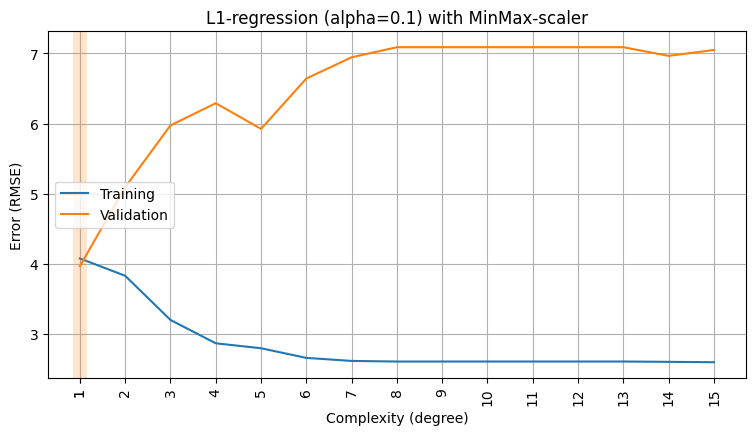

In [83]:
plot_fitting_graph(DEGREES, rmse_train_scaler, rmse_test_scaler, xlabel='Complexity (degree)', ylabel='Error (RMSE)', 
                   title='L1-regression (alpha=0.1) with MinMax-scaler')

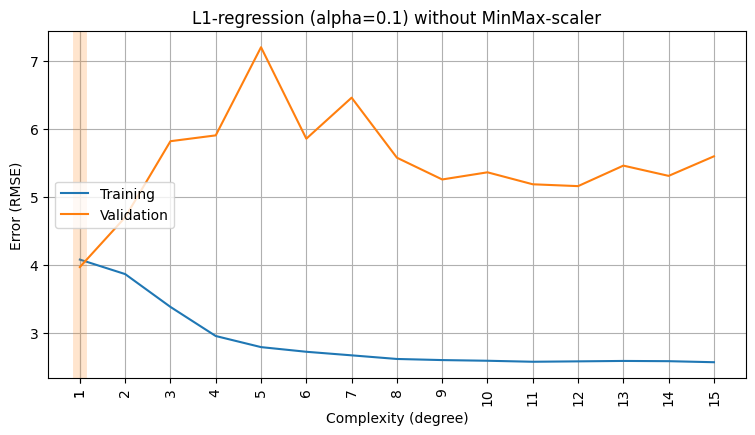

In [84]:
plot_fitting_graph(DEGREES, rmse_train_no_scaler, rmse_test_no_scaler, xlabel='Complexity (degree)', ylabel='Error (RMSE)', 
                   title='L1-regression (alpha=0.1) without MinMax-scaler')

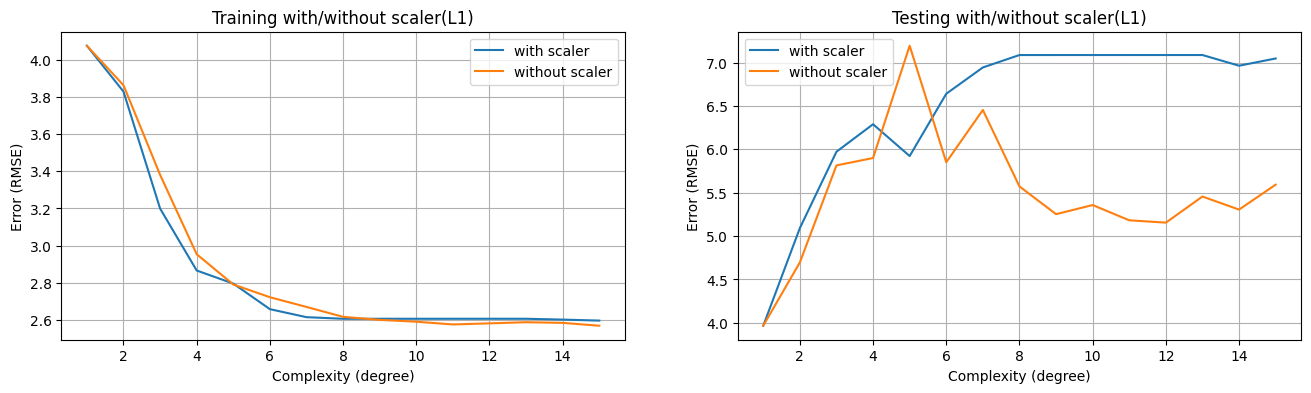

In [85]:
fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(16,4))

axes[0].plot(DEGREES, rmse_train_scaler, label = 'with scaler')
axes[0].plot(DEGREES, rmse_train_no_scaler, label = "without scaler")
axes[0].legend()
axes[0].grid(True)
axes[0].set_ylabel('Error (RMSE)')
axes[0].set_xlabel('Complexity (degree)')
axes[0].set_title('Training with/without scaler(L1)')

axes[1].plot(DEGREES, rmse_test_scaler, label='with scaler')
axes[1].plot(DEGREES, rmse_test_no_scaler, label='without scaler')
axes[0].legend()
axes[1].grid(True)
axes[1].set_ylabel('Error (RMSE)')
axes[1].set_xlabel('Complexity (degree)')
axes[1].set_title('Testing with/without scaler(L1)')
axes[1].legend()

Для лассо-регуляризации тестовых данных показатель RMSE хуже, если данные масштабированны, однако на обучающие данные сильного влияния масштабирование не оказывает.

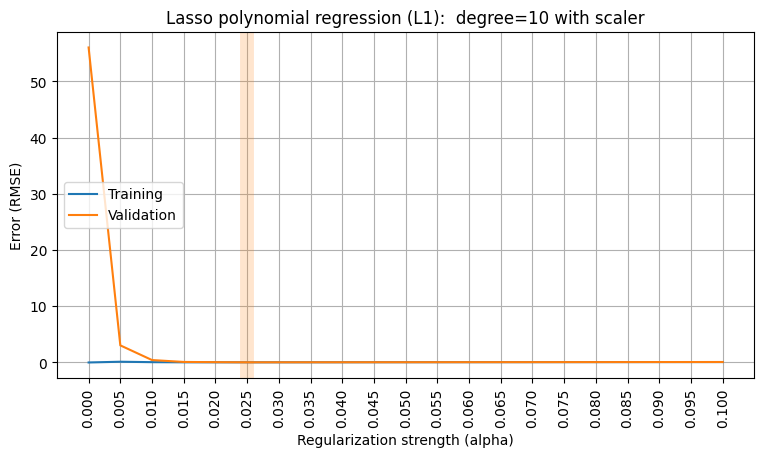

In [100]:
rmse_train_scaler_l1, rmse_valid_scaler_l1 = [], []
degree = 10
for alpha in ALPHAS:    
    l1_results_scaler = cross_validate(make_model(degree=degree, penalty='L1', alpha=alpha), 
                             X_hw_scaler, X_hw, cv=5,
                             return_estimator=True, return_train_score=True,
                             scoring='neg_root_mean_squared_error')
    rmse_train_scaler_l1.append(-np.mean(l1_results_scaler['train_score']))
    rmse_valid_scaler_l1.append(-np.mean(l1_results_scaler['test_score']))
    
plot_fitting_graph(ALPHAS, rmse_train_scaler_l1, rmse_valid_scaler_l1,
                   xlabel='Regularization strength (alpha)', ylabel='Error (RMSE)',
                   title='Lasso polynomial regression (L1):  degree=10 with scaler')

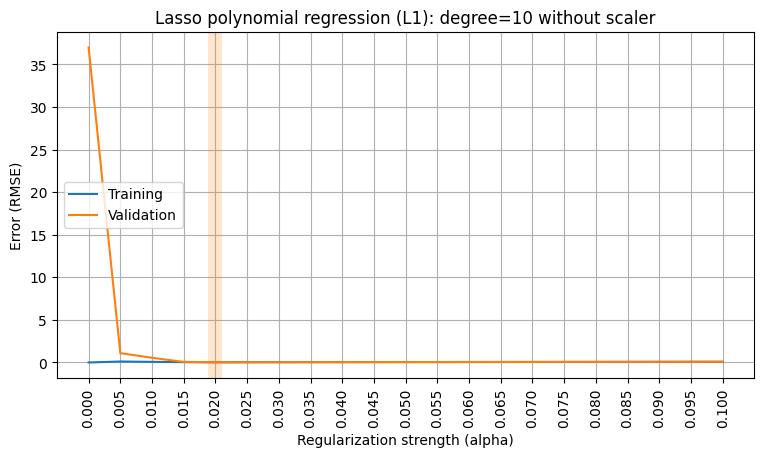

In [101]:
rmse_train_noscaler_l1, rmse_valid_noscaler_l1 = [], []
degree = 10
for alpha in ALPHAS:    
    l1_results_noscaler = cross_validate(make_model(degree=degree, penalty='L1', alpha=alpha), 
                             X_hw, X_hw, cv=5,
                             return_estimator=True, return_train_score=True,
                             scoring='neg_root_mean_squared_error')
    rmse_train_noscaler_l1.append(-np.mean(l1_results_noscaler['train_score']))
    rmse_valid_noscaler_l1.append(-np.mean(l1_results_noscaler['test_score']))
    
plot_fitting_graph(ALPHAS, rmse_train_noscaler_l1, rmse_valid_noscaler_l1,
                   xlabel='Regularization strength (alpha)', ylabel='Error (RMSE)',
                   title='Lasso polynomial regression (L1): degree=10 without scaler')

Для L1-регуляризация при отсутствии масштабирования входных признаков требуется меньшая сила регуляризаци, чем при ее наличии.

#### L2

In [88]:
MAX_DEGREE = 15
DEGREES = np.linspace(1, MAX_DEGREE, MAX_DEGREE+1, dtype=int)

# With StandardScaler
rmse_train_scaler_l2, rmse_test_scaler_l2 = [], []
for degree in DEGREES:
    reg = make_model(degree, penalty='L2', alpha=0.1 ).fit(X_train_scaler, y_train_t4)
    rmse_train_scaler_l2.append(rmse(reg.predict(X_train_scaler), y_train_t4))
    rmse_test_scaler_l2.append(rmse(reg.predict(X_test_scaler), y_test_t4))

# without StandardScaler
rmse_train_no_scaler_l2, rmse_test_no_scaler_l2 = [], []
for degree in DEGREES:
    reg = make_model(degree, penalty='L2', alpha=0.1).fit(X_train_t4, y_train_t4)
    rmse_train_no_scaler_l2.append(rmse(reg.predict(X_train_t4), y_train_t4))
    rmse_test_no_scaler_l2.append(rmse(reg.predict(X_test_t4), y_test_t4))

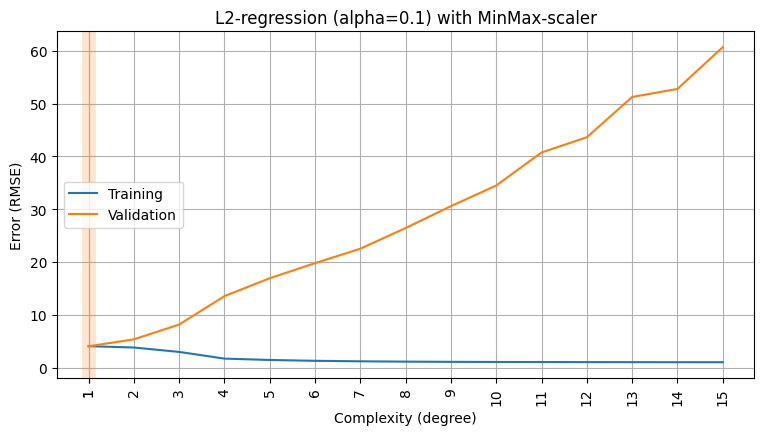

In [89]:
plot_fitting_graph(DEGREES, rmse_train_scaler_l2, rmse_test_scaler_l2, xlabel='Complexity (degree)', ylabel='Error (RMSE)', 
                   title='L2-regression (alpha=0.1) with MinMax-scaler')

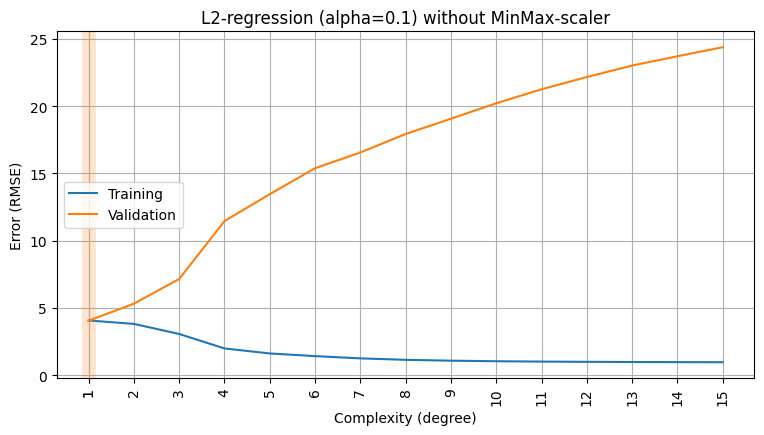

In [90]:
plot_fitting_graph(DEGREES, rmse_train_no_scaler_l2, rmse_test_no_scaler_l2, xlabel='Complexity (degree)', ylabel='Error (RMSE)', 
                   title='L2-regression (alpha=0.1) without MinMax-scaler')

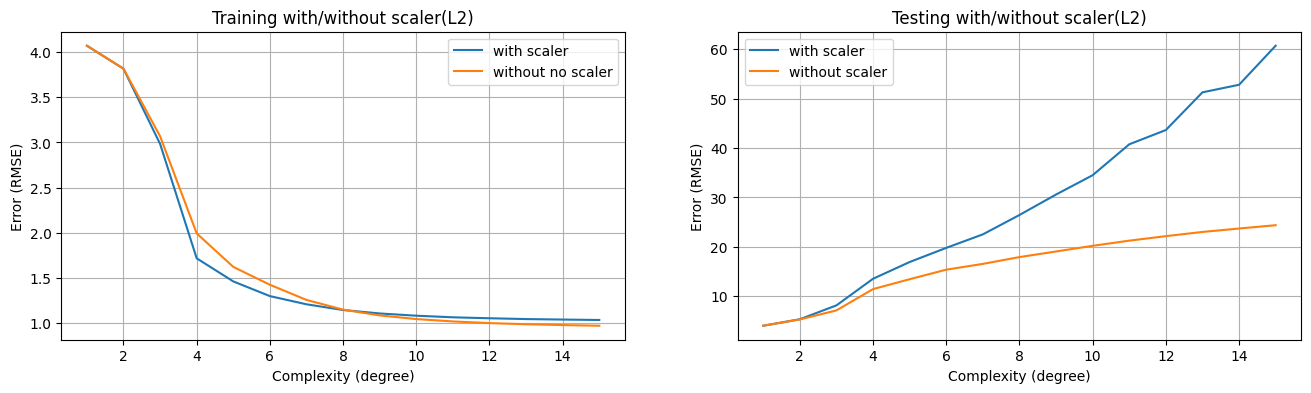

In [91]:
fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(16,4))

axes[0].plot(DEGREES, rmse_train_scaler_l2, label = 'with scaler')
axes[0].plot(DEGREES, rmse_train_no_scaler_l2, label = 'without no scaler')
axes[0].grid(True)
axes[0].set_ylabel('Error (RMSE)')
axes[0].set_xlabel('Complexity (degree)')
axes[0].set_title('Training with/without scaler(L2)')
axes[0].legend()  

axes[1].plot(DEGREES, rmse_test_scaler_l2, label = 'with scaler')
axes[1].plot(DEGREES, rmse_test_no_scaler_l2, label = 'without scaler')
axes[1].grid(True)
axes[1].set_ylabel('Error (RMSE)')
axes[1].set_xlabel('Complexity (degree)')
axes[1].set_title('Testing with/without scaler(L2)')
axes[1].legend()  

Масшабирование тестовых данных при L2-регуляризации плохо повлияло на среднеквадратичную ошибку, так как тестовые данные без масштабирования имеют меньшую RMSE. На обучающие данные масштабирование большого влияния не оказывает.

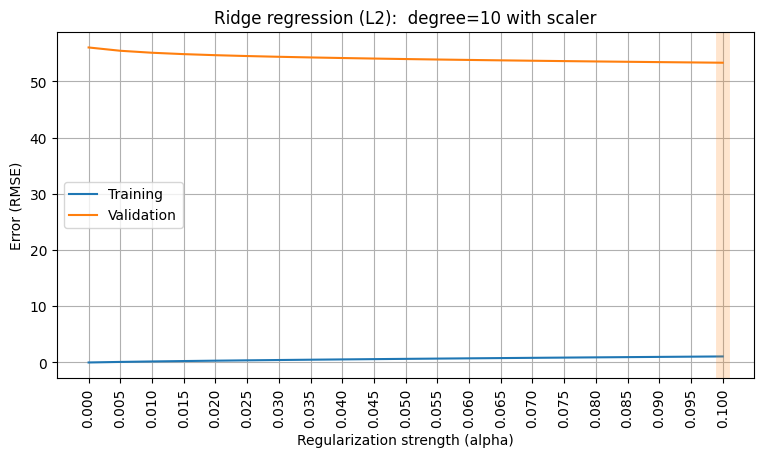

In [106]:
rmse_train_scaler_l2, rmse_valid_scaler_l2 = [], []
degree = 10
for alpha in ALPHAS:    
    l2_results_scaler = cross_validate(make_model(degree=degree, penalty='L2', alpha=alpha), 
                             X_hw_scaler, X_hw, cv=5,
                             return_estimator=True, return_train_score=True,
                             scoring='neg_root_mean_squared_error')
    rmse_train_scaler_l2.append(-np.mean(l2_results_scaler['train_score']))
    rmse_valid_scaler_l2.append(-np.mean(l2_results_scaler['test_score']))
    
plot_fitting_graph(ALPHAS, rmse_train_scaler_l2, rmse_valid_scaler_l2,
                   xlabel='Regularization strength (alpha)', ylabel='Error (RMSE)',
                   title='Ridge regression (L2):  degree=10 with scaler')

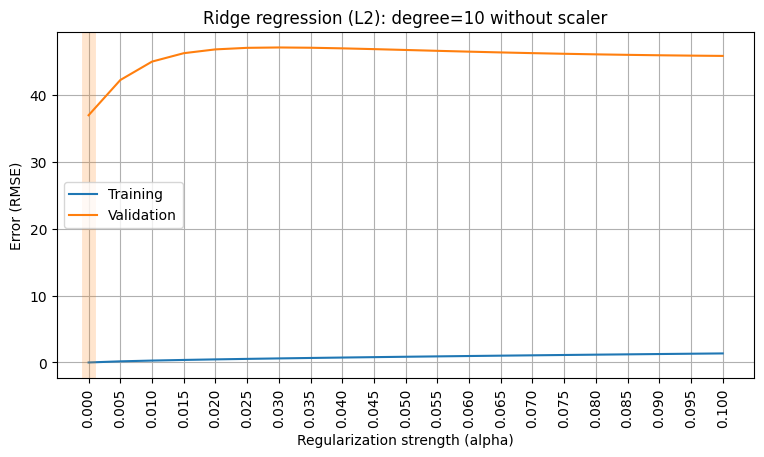

In [104]:
rmse_train_noscaler_l2, rmse_valid_noscaler_l2 = [], []
degree = 10
for alpha in ALPHAS:    
    l2_results_noscaler = cross_validate(make_model(degree=degree, penalty='L2', alpha=alpha), 
                             X_hw, X_hw, cv=5,
                             return_estimator=True, return_train_score=True,
                             scoring='neg_root_mean_squared_error')
    rmse_train_noscaler_l2.append(-np.mean(l2_results_noscaler['train_score']))
    rmse_valid_noscaler_l2.append(-np.mean(l2_results_noscaler['test_score']))
    
plot_fitting_graph(ALPHAS, rmse_train_noscaler_l2, rmse_valid_noscaler_l2,
                   xlabel='Regularization strength (alpha)', ylabel='Error (RMSE)',
                   title='Ridge regression (L2): degree=10 without scaler')

Для L2-регуляризации при отсутствии масштабирования требуется меньшая сила регуляризации.

#### Summary



Для L1- и L2-регуляризаций при отсутствии масштабирования входных признаков требуется меньшая сила регуляризаци, чем при ее наличии. При этом отсутствия нормализации в большей 
степени снижает эффективность L1-регуляризации, чем L2-регуляризацию.

Использование ненормированных данных в случае с L1- и L2-регуляризацией приводит к увеличению степени переобученности модели предсказания.

Масштабирование уравнивает вклад признаков. Числовые параметры могут быть значительно смещены относительно начала координат, когда паказатели например варьируются от 100 до 150, что означает, что меньших значений не будет. Для повышения точности используют масштабирование (нормализацию).